# 1. Introduction

## Customer Churn Prediction

Customer churn refers to the situation where a customer stops doing business with a company over a period of time. In the retail industry, retaining existing customers is often more cost-effective than acquiring new ones. Therefore, identifying customers who are likely to churn is an important business objective.

Unlike Customer Lifetime Value (CLV) Prediction, which estimates the future revenue a customer may generate, Churn Prediction focuses on determining whether a customer is likely to become inactive.

Since the Online Retail dataset does not explicitly indicate whether a customer has churned, we will create our own churn definition based on customer purchase behavior. A customer who has not made any purchases for a specified period before the end of the observation window will be considered a churned customer.

This transforms the problem into a **Supervised Machine Learning Classification** task, where the target variable is:

- **0 → Active Customer**
- **1 → Churned Customer**

---

## Business Problem

Customer retention is one of the most important factors influencing business growth and profitability. Losing valuable customers can lead to reduced revenue, lower customer lifetime value, and increased marketing costs.

The business wants to proactively identify customers who are likely to stop purchasing so that targeted retention strategies can be implemented before they are lost.

Examples of such strategies include:

- Personalized discount offers
- Email marketing campaigns
- Loyalty rewards
- Product recommendations
- Customer engagement programs

Accurately identifying at-risk customers allows businesses to allocate marketing resources more efficiently and improve long-term customer relationships.

---

## Machine Learning Objective

The objective of this phase is to build a classification model capable of predicting whether a customer is likely to churn based on their historical purchasing behavior.

The model will learn patterns from customer-level features such as:

- Purchase frequency
- Total spending
- Recency of purchases
- Product diversity
- Revenue patterns
- Purchasing behaviour

Multiple classification algorithms will be trained and evaluated to identify the model that provides the best predictive performance.

---

## Workflow

The overall workflow for Customer Churn Prediction is illustrated below:

Transaction Data

↓

Define Observation Period

↓

Create Churn Target

↓

Customer Feature Engineering

↓

Prepare Modeling Dataset

↓

Train-Test Split

↓

Feature Scaling

↓

Train Multiple Classification Models

↓

Evaluate Model Performance

↓

Select Best Model

↓

Predict Customer Churn

↓

Save Model and Predictions

---

## Expected Outputs

At the end of this phase, the following outputs will be generated:

### Datasets

- customer_churn_dataset.csv
- customer_churn_predictions.csv

### Model Files

- churn_model.pkl
- churn_scaler.pkl

### Figures

- churn_distribution.png
- churn_pie_chart.png
- churn_correlation_heatmap.png
- confusion_matrix.png
- roc_curve.png
- model_comparison_churn.png
- feature_importance_churn.png

---

## Business Value

This model will help businesses:

- Identify customers at high risk of leaving.
- Improve customer retention strategies.
- Reduce revenue loss caused by inactive customers.
- Optimize marketing budgets by targeting the right customers.
- Increase overall Customer Lifetime Value (CLV).
- Support data-driven business decision making.

# 2. Import Required Libraries

In this section, we import all the libraries required for data manipulation, visualization, preprocessing, model building, evaluation, and model saving.

Keeping all imports at the beginning of the notebook makes the project organized, readable, and easy to maintain.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

In [2]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Ignore unnecessary warnings
import warnings

warnings.filterwarnings("ignore")

In [4]:
# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

In [6]:
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [7]:
# Save and Load Models
import joblib
print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


### Section Summary

In this section, we imported all the libraries required for the Customer Churn Prediction workflow. These libraries will be used throughout the notebook for data preprocessing, visualization, model training, evaluation, and saving the final model for deployment.

# 3. Load the Dataset

Before building the churn prediction model, we first load the cleaned transaction dataset created in the previous phases.

This dataset contains all the cleaned customer transactions along with the engineered date and revenue-related features. It will serve as the foundation for creating the customer-level churn dataset in the next sections.

In [8]:
from pathlib import Path

In [9]:
# Dataset Path
DATA_PATH = Path("../data/processed/final_cleaned_dataset.csv")

In [10]:
# Load Dataset
df = pd.read_csv(DATA_PATH)

In [11]:
# Display Dataset Shape
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 797815
Number of Columns : 21


In [12]:
# Display First Five Rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,...,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,...,12,December,1,Tuesday,7,4,1,49,False,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,...,12,December,1,Tuesday,7,4,1,49,False,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,...,12,December,1,Tuesday,7,4,1,49,False,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,...,12,December,1,Tuesday,7,4,1,49,False,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,...,12,December,1,Tuesday,7,4,1,49,False,Morning


In [13]:
# Display Data Types
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
IsCancelled       bool
Revenue        float64
Year             int64
Month            int64
MonthName       object
Day              int64
DayName         object
Hour             int64
Quarter          int64
DayOfWeek        int64
Week             int64
IsWeekend         bool
TimeOfDay       object
dtype: object

In [14]:
# Missing Values
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
IsCancelled    0
Revenue        0
Year           0
Month          0
MonthName      0
Day            0
DayName        0
Hour           0
Quarter        0
DayOfWeek      0
Week           0
IsWeekend      0
TimeOfDay      0
dtype: int64

In [15]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    797815 non-null  object 
 1   StockCode    797815 non-null  object 
 2   Description  797815 non-null  object 
 3   Quantity     797815 non-null  int64  
 4   InvoiceDate  797815 non-null  object 
 5   UnitPrice    797815 non-null  float64
 6   CustomerID   797815 non-null  float64
 7   Country      797815 non-null  object 
 8   IsCancelled  797815 non-null  bool   
 9   Revenue      797815 non-null  float64
 10  Year         797815 non-null  int64  
 11  Month        797815 non-null  int64  
 12  MonthName    797815 non-null  object 
 13  Day          797815 non-null  int64  
 14  DayName      797815 non-null  object 
 15  Hour         797815 non-null  int64  
 16  Quarter      797815 non-null  int64  
 17  DayOfWeek    797815 non-null  int64  
 18  Week         797815 non-

In [16]:
# List All Columns
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'IsCancelled',
 'Revenue',
 'Year',
 'Month',
 'MonthName',
 'Day',
 'DayName',
 'Hour',
 'Quarter',
 'DayOfWeek',
 'Week',
 'IsWeekend',
 'TimeOfDay']

### Section Summary

In this section, we loaded the cleaned transaction dataset that was prepared during the Data Cleaning phase. We also verified its structure by checking the dataset dimensions, previewing the records, inspecting data types, and confirming that there were no unexpected missing values.

This validation step ensures that the dataset is ready for defining the churn target and creating customer-level features in the next section.

# 4. Define Customer Churn

The Online Retail dataset does not contain a column that directly indicates whether a customer has churned. Therefore, we need to create our own churn definition based on customer purchasing behavior.

In this project, a customer will be considered **churned** if they have not made any purchases during the last **90 days** of the dataset. Otherwise, the customer will be considered **active**.

This newly created target variable (`Churn`) will be used to train our machine learning classification models in the later sections.

In [17]:
# Convert InvoiceDate to datetime (if not already)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [18]:
# Find the last transaction date in the dataset
last_date = df["InvoiceDate"].max()

print("Last Transaction Date :", last_date)

Last Transaction Date : 2011-12-09 12:50:00


In [19]:
# Define churn threshold
CHURN_DAYS = 90

# Calculate cutoff date
cutoff_date = last_date - pd.Timedelta(days=CHURN_DAYS)

print("Churn Cutoff Date :", cutoff_date)

Churn Cutoff Date : 2011-09-10 12:50:00


In [20]:
# Last purchase date of each customer
last_purchase = (
    df.groupby("CustomerID")["InvoiceDate"]
      .max()
      .reset_index()
)

last_purchase.head()

,CustomerID,InvoiceDate
0,12346.0,2011-01-18 10:17:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [21]:
# Create Churn column
last_purchase["Churn"] = (
    last_purchase["InvoiceDate"] < cutoff_date
).astype(int)

last_purchase.head()

,CustomerID,InvoiceDate,Churn
0,12346.0,2011-01-18 10:17:00,1
1,12347.0,2011-12-07 15:52:00,0
2,12348.0,2011-09-25 13:13:00,0
3,12349.0,2011-11-21 09:51:00,0
4,12350.0,2011-02-02 16:01:00,1


In [22]:
# Churn distribution
last_purchase["Churn"].value_counts()

Churn
1    3022
0    2917
Name: count, dtype: int64

In [23]:
# Percentage distribution
(
    last_purchase["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn
1    50.88
0    49.12
Name: proportion, dtype: float64

In [24]:
# Merge churn target with transaction data
df = df.merge(
    last_purchase[["CustomerID", "Churn"]],
    on="CustomerID",
    how="left"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,...,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay,Churn
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,...,December,1,Tuesday,7,4,1,49,False,Morning,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,...,December,1,Tuesday,7,4,1,49,False,Morning,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,...,December,1,Tuesday,7,4,1,49,False,Morning,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,...,December,1,Tuesday,7,4,1,49,False,Morning,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,...,December,1,Tuesday,7,4,1,49,False,Morning,1


In [25]:
df[["CustomerID", "InvoiceDate", "Churn"]].head()

,CustomerID,InvoiceDate,Churn
0,13085.0,2009-12-01 07:45:00,1
1,13085.0,2009-12-01 07:45:00,1
2,13085.0,2009-12-01 07:45:00,1
3,13085.0,2009-12-01 07:45:00,1
4,13085.0,2009-12-01 07:45:00,1


### Section Summary

In this section, we created the target variable required for the churn prediction model. Since the dataset does not explicitly identify churned customers, we defined churn based on customer inactivity.

A customer who had not made a purchase during the last **90 days** of the observation period was labeled as **Churn = 1**, while all remaining customers were labeled as **Churn = 0**.

This newly created target variable transforms our business problem into a **supervised binary classification problem**, enabling us to train machine learning models to identify customers who are at risk of churning.

# 5. Prepare the Customer Churn Dataset

In this section, we prepare the dataset that will be used to train the churn prediction models.

Instead of recreating all customer-level features, we use the `customer_features.csv` dataset generated during the Feature Engineering phase. We then merge it with the churn labels created in the previous section to form the final modeling dataset.

This approach keeps the project modular, avoids duplicate computations, and ensures consistency across different machine learning models.

In [26]:
# Load customer-level features
customer_features = pd.read_csv("../data/processed/customer_features.csv")

customer_features.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,27,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765,United Kingdom
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,126,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000,Iceland
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,25,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000,Finland
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,138,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000,Italy
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,17,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,Norway


In [27]:
print("Shape :", customer_features.shape)

customer_features.info()

Shape : (5878, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               5878 non-null   float64
 1   Recency                  5878 non-null   int64  
 2   Frequency                5878 non-null   int64  
 3   Monetary                 5878 non-null   float64
 4   TotalQuantity            5878 non-null   int64  
 5   AvgQuantity              5878 non-null   float64
 6   MedianQuantity           5878 non-null   float64
 7   MaxQuantity              5878 non-null   int64  
 8   MinQuantity              5878 non-null   int64  
 9   QuantitySTD              5878 non-null   float64
 10  AvgRevenue               5878 non-null   float64
 11  MedianRevenue            5878 non-null   float64
 12  MaxRevenue               5878 non-null   float64
 13  MinRevenue               5878 non-null   float64
 14  Reven

In [28]:
# Extract one churn label per customer
customer_churn = (
    df[["CustomerID", "Churn"]]
    .drop_duplicates()
)

customer_churn.head()

,CustomerID,Churn
0,13085.0,1
12,13078.0,0
31,15362.0,1
54,18102.0,0
71,12682.0,0


In [29]:
customer_churn_dataset = customer_features.merge(
    customer_churn,
    on="CustomerID",
    how="inner"
)

customer_churn_dataset.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,Churn
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765,United Kingdom,1
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000,Iceland,0
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000,Finland,0
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000,Italy,0
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,Norway,1


In [30]:
print(f"Number of Customers : {customer_churn_dataset.shape[0]}")
print(f"Number of Features  : {customer_churn_dataset.shape[1]}")

Number of Customers : 5878
Number of Features  : 27


In [31]:
customer_churn_dataset.isnull().sum()

CustomerID                 0
Recency                    0
Frequency                  0
Monetary                   0
TotalQuantity              0
AvgQuantity                0
MedianQuantity             0
MaxQuantity                0
MinQuantity                0
QuantitySTD                0
AvgRevenue                 0
MedianRevenue              0
MaxRevenue                 0
MinRevenue                 0
RevenueSTD                 0
RevenueRange               0
UniqueProducts             0
AvgProductsPerInvoice      0
ActiveMonths               0
PurchaseSpan               0
WeekendPurchaseRate        0
AvgDaysBetweenPurchases    0
CancelledTransactions      0
CancelledRevenue           0
CancellationRate           0
Country                    0
Churn                      0
dtype: int64

In [32]:
customer_churn_dataset.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,Churn
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765,United Kingdom,1
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000,Iceland,0
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000,Finland,0
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000,Italy,0
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,Norway,1


In [33]:
customer_churn_dataset.to_csv(
    "../data/processed/customer_churn_dataset.csv",
    index=False
)

print("Customer churn dataset saved successfully.")

Customer churn dataset saved successfully.


In [34]:
customer_churn_dataset.columns.tolist()

['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'TotalQuantity',
 'AvgQuantity',
 'MedianQuantity',
 'MaxQuantity',
 'MinQuantity',
 'QuantitySTD',
 'AvgRevenue',
 'MedianRevenue',
 'MaxRevenue',
 'MinRevenue',
 'RevenueSTD',
 'RevenueRange',
 'UniqueProducts',
 'AvgProductsPerInvoice',
 'ActiveMonths',
 'PurchaseSpan',
 'WeekendPurchaseRate',
 'AvgDaysBetweenPurchases',
 'CancelledTransactions',
 'CancelledRevenue',
 'CancellationRate',
 'Country',
 'Churn']

### Section Summary

In this section, we prepared the final customer-level dataset for churn prediction by combining the engineered customer features from Phase 4 with the churn labels created in the previous section.

By reusing the existing feature dataset instead of recreating it, we maintain consistency across the project, reduce duplicate code, and follow a modular workflow. The resulting dataset contains one row per customer along with the target variable (`Churn`) and is now ready for exploratory analysis and machine learning model development.

# 6. Explore the Target Variable

Before training any machine learning model, it is important to understand the distribution of the target variable.

In this section, we analyze the number and percentage of active and churned customers. This helps us identify whether the dataset is balanced or imbalanced, which can influence model selection and evaluation.

In [35]:
# Count of each class
customer_churn_dataset["Churn"].value_counts()

Churn
1    2961
0    2917
Name: count, dtype: int64

In [36]:
# Percentage distribution
(
    customer_churn_dataset["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn
1    50.37
0    49.63
Name: proportion, dtype: float64

In [37]:
# Summary table
churn_summary = (
    customer_churn_dataset["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customers")
)

churn_summary["Percentage"] = (
    churn_summary["Customers"] /
    churn_summary["Customers"].sum() * 100
).round(2)

churn_summary["Customer Status"] = churn_summary["Churn"].map({
    0: "Active",
    1: "Churned"
})

churn_summary = churn_summary[
    ["Customer Status", "Customers", "Percentage"]
]

churn_summary

,Customer Status,Customers,Percentage
0,Churned,2961,50.37
1,Active,2917,49.63


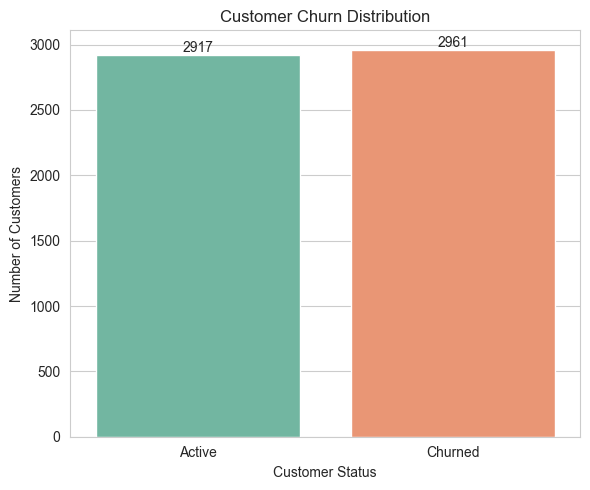

In [38]:
# Churn Distribution
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=customer_churn_dataset,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

ax.set_xticklabels(["Active", "Churned"])

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

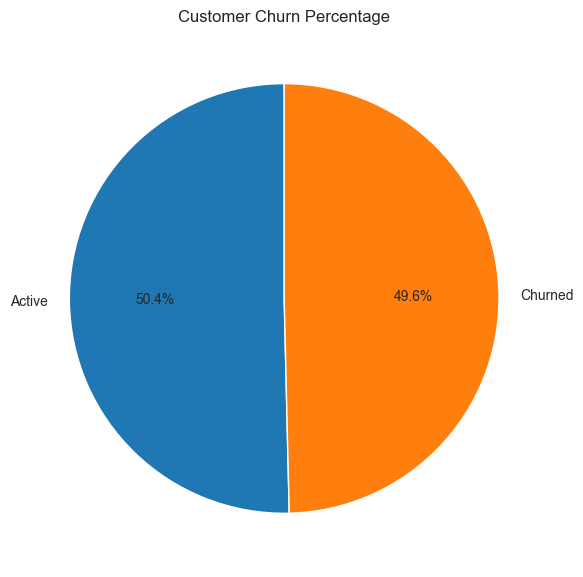

In [39]:
# Pie Chart
plt.figure(figsize=(6,6))

customer_churn_dataset["Churn"].value_counts().plot(
    kind="pie",
    labels=["Active", "Churned"],
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Check class balance
active = (customer_churn_dataset["Churn"] == 0).sum()
churned = (customer_churn_dataset["Churn"] == 1).sum()

ratio = active / churned

print(f"Active Customers  : {active}")
print(f"Churned Customers : {churned}")
print(f"Active : Churned Ratio = {ratio:.2f} : 1")

Active Customers  : 2917
Churned Customers : 2961
Active : Churned Ratio = 0.99 : 1


### Section Summary

In this section, we analyzed the distribution of the target variable (`Churn`). We examined both the number and percentage of active and churned customers using summary tables and visualizations.

Understanding the class distribution is an important step before model training because highly imbalanced datasets may require special techniques such as class weighting, oversampling, or alternative evaluation metrics. The insights gained here will guide our choice of models and evaluation strategy in the following sections.

# 7. Feature Correlation Analysis

Before training machine learning models, it is helpful to understand how the numerical features relate to each other.

A correlation matrix shows the strength and direction of the relationship between pairs of features. This helps identify highly correlated variables, understand feature relationships, and gain insights into the dataset before model training.

In [41]:
# Select only numerical columns
numerical_features = customer_churn_dataset.select_dtypes(
    include=["number"]
)

numerical_features.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Churn
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,27,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765,1
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,126,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000,0
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,25,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000,0
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,138,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000,0
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,17,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,1


In [42]:
# Compute correlation matrix
correlation_matrix = numerical_features.corr()

correlation_matrix.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Churn
CustomerID,1.000000,0.016786,-0.004828,-0.010386,-0.017865,0.007835,0.001425,-0.010139,0.011709,0.002505,...,0.002547,-0.006293,-0.011732,0.010549,0.030275,0.006706,-0.046932,0.011063,-0.092611,0.016039
Recency,0.016786,1.000000,-0.257013,-0.124956,-0.110038,-0.007581,0.022906,-0.016334,0.038975,-0.011497,...,-0.325477,-0.094754,-0.470977,-0.563569,0.004570,-0.234667,-0.193427,0.018373,-0.064091,0.796822
Frequency,-0.004828,-0.257013,1.000000,0.627920,0.571799,0.003176,0.010678,0.045700,-0.030772,0.006391,...,0.693113,-0.007123,0.625677,0.441936,-0.011964,-0.095663,0.779908,-0.155889,0.093691,-0.251760
Monetary,-0.010386,-0.124956,0.627920,1.000000,0.874546,0.175985,0.084564,0.216800,0.000829,0.178997,...,0.407911,0.019389,0.317394,0.212695,-0.028787,-0.057900,0.459909,-0.347220,0.063834,-0.127608
TotalQuantity,-0.017865,-0.110038,0.571799,0.874546,1.000000,0.206385,0.268231,0.298795,0.014721,0.196847,...,0.388982,0.015234,0.301803,0.201079,-0.031415,-0.056469,0.414533,-0.305498,0.060783,-0.117053


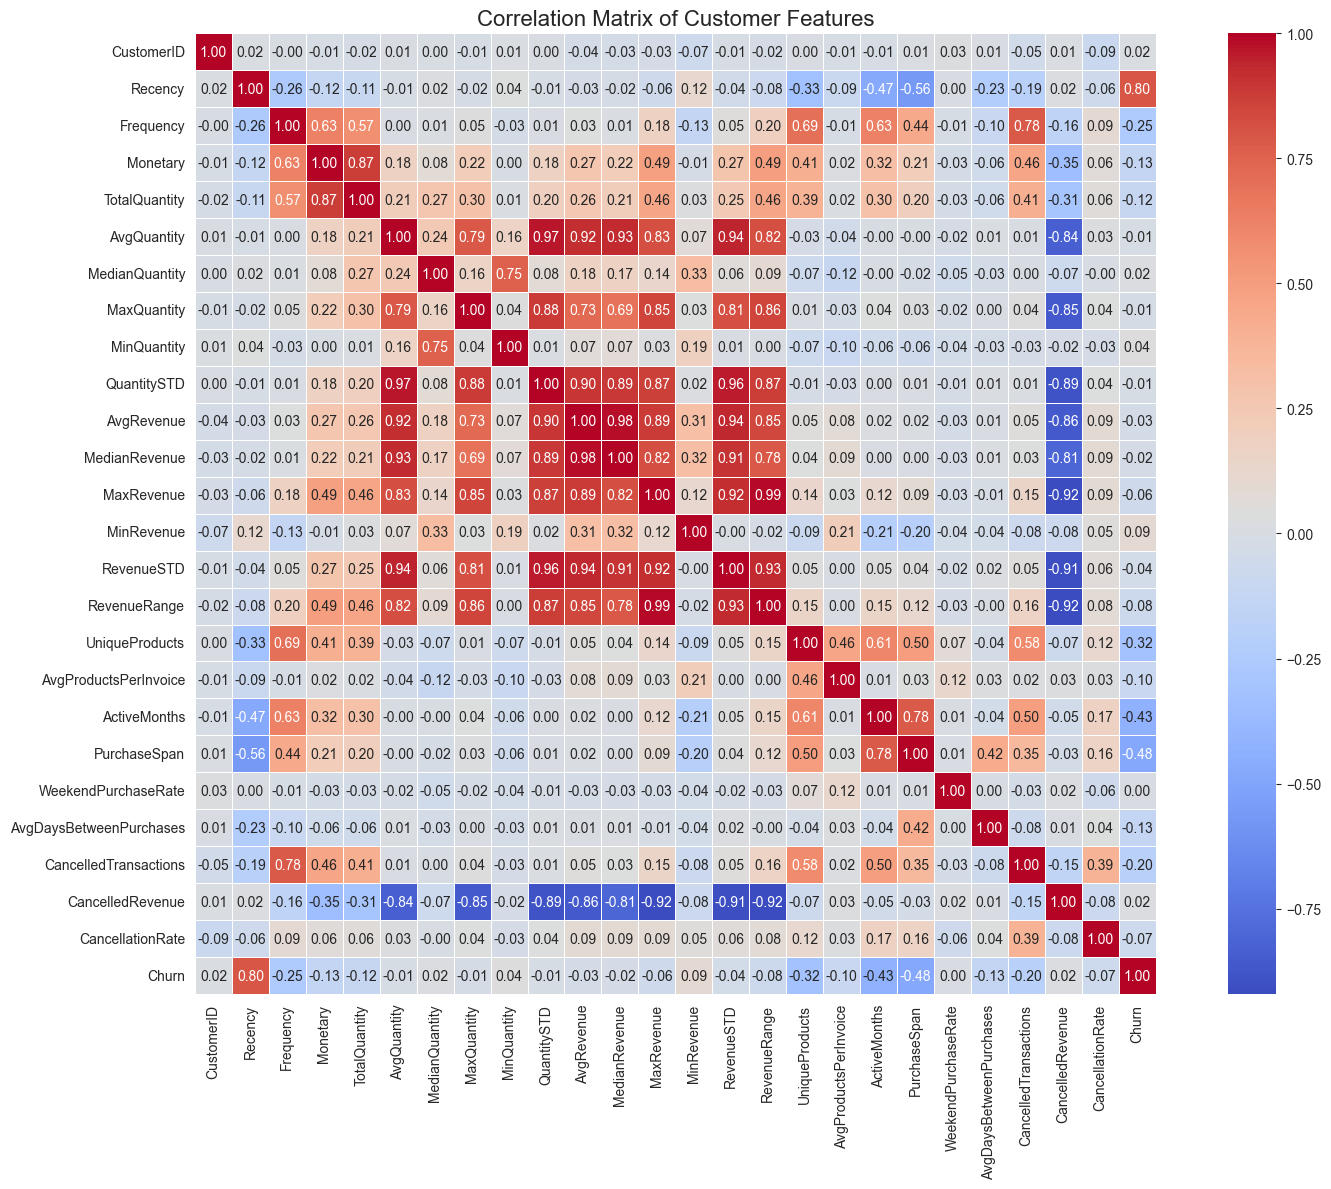

In [43]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Customer Features", fontsize=16)

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# Identify highly correlated feature pairs
threshold = 0.80

high_corr = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"].abs() >= threshold
].sort_values(
    by="Correlation",
    ascending=False
)

high_corr

,Feature 1,Feature 2,Correlation
236,MaxRevenue,RevenueRange,0.990352
205,AvgRevenue,MedianRevenue,0.983609
118,AvgQuantity,QuantitySTD,0.968602
193,QuantitySTD,RevenueSTD,0.962469
123,AvgQuantity,RevenueSTD,0.943210
208,AvgRevenue,RevenueSTD,0.938994
259,RevenueSTD,RevenueRange,0.927430
120,AvgQuantity,MedianRevenue,0.925804
235,MaxRevenue,RevenueSTD,0.920724
119,AvgQuantity,AvgRevenue,0.918919


In [45]:
# Correlation with Churn
churn_corr = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

churn_corr

Recency                    0.796822
MinRevenue                 0.092326
MinQuantity                0.041259
MedianQuantity             0.023435
CancelledRevenue           0.019463
CustomerID                 0.016039
WeekendPurchaseRate        0.004060
AvgQuantity               -0.007732
QuantitySTD               -0.010797
MaxQuantity               -0.013860
MedianRevenue             -0.024499
AvgRevenue                -0.030644
RevenueSTD                -0.038369
MaxRevenue                -0.063551
CancellationRate          -0.072308
RevenueRange              -0.076899
AvgProductsPerInvoice     -0.100522
TotalQuantity             -0.117053
AvgDaysBetweenPurchases   -0.126063
Monetary                  -0.127608
CancelledTransactions     -0.198419
Frequency                 -0.251760
UniqueProducts            -0.318267
ActiveMonths              -0.427635
PurchaseSpan              -0.482827
Name: Churn, dtype: float64

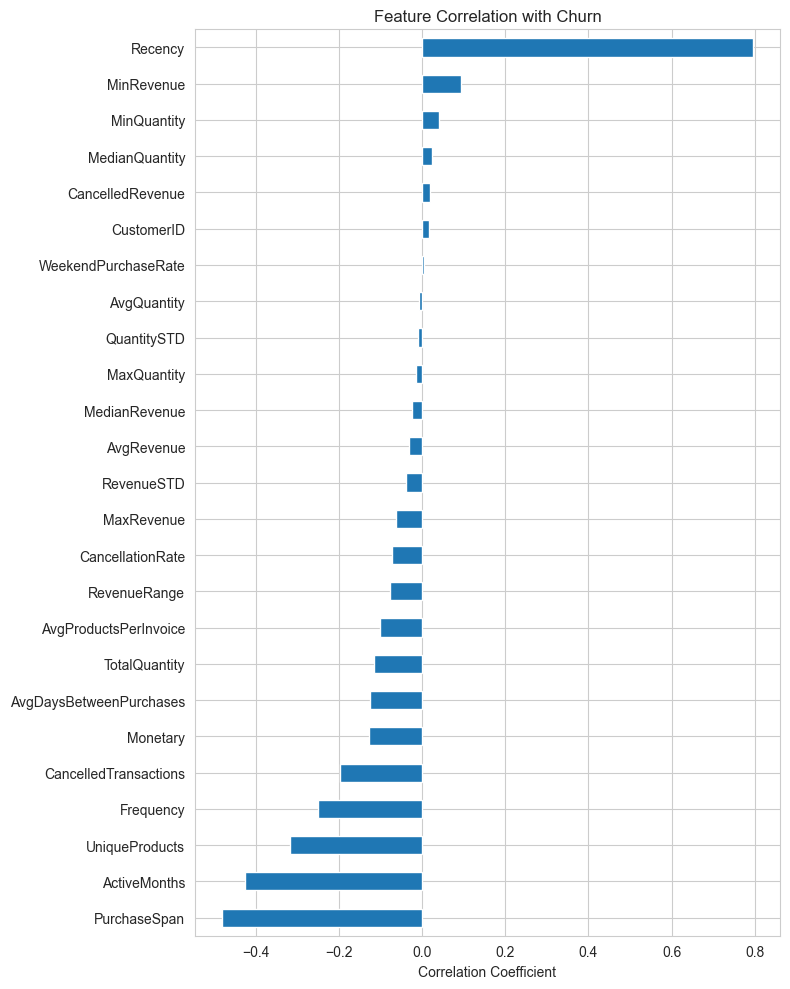

In [46]:
plt.figure(figsize=(8, 10))

churn_corr.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation Coefficient")

plt.tight_layout()

plt.show()

### Section Summary

In this section, we explored the relationships between the numerical features using a correlation matrix. We also identified highly correlated feature pairs and examined how each feature is related to the target variable (`Churn`).

This analysis helps us better understand the dataset and detect potential multicollinearity. Although tree-based models such as Random Forest and Gradient Boosting are generally robust to correlated features, this step provides valuable insights into the data and supports informed feature selection in future iterations of the project.

# 8. Train-Test Split

Before training the machine learning models, we divide the dataset into training and testing sets.

The training set is used to learn the relationship between customer features and churn, while the testing set is used to evaluate how well the trained model performs on unseen data.

In this project, we use an **80:20 split**, where 80% of the data is used for training and the remaining 20% is reserved for testing.

In [47]:
# Separate features and target variable
X = customer_churn_dataset.drop(columns=["CustomerID", "Churn"])

y = customer_churn_dataset["Churn"]

In [48]:
print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (5878, 25)
Target Shape         : (5878,)


In [49]:
X.columns.tolist()

['Recency',
 'Frequency',
 'Monetary',
 'TotalQuantity',
 'AvgQuantity',
 'MedianQuantity',
 'MaxQuantity',
 'MinQuantity',
 'QuantitySTD',
 'AvgRevenue',
 'MedianRevenue',
 'MaxRevenue',
 'MinRevenue',
 'RevenueSTD',
 'RevenueRange',
 'UniqueProducts',
 'AvgProductsPerInvoice',
 'ActiveMonths',
 'PurchaseSpan',
 'WeekendPurchaseRate',
 'AvgDaysBetweenPurchases',
 'CancelledTransactions',
 'CancelledRevenue',
 'CancellationRate',
 'Country']

In [50]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (4702, 25)
Testing Features  : (1176, 25)

Training Labels   : (4702,)
Testing Labels    : (1176,)


In [52]:
print("Training Set")
print(y_train.value_counts(normalize=True).round(3))

print("\n" + "-" * 40 + "\n")

print("Testing Set")
print(y_test.value_counts(normalize=True).round(3))

Training Set
Churn
1    0.504
0    0.496
Name: proportion, dtype: float64

----------------------------------------

Testing Set
Churn
1    0.503
0    0.497
Name: proportion, dtype: float64


In [53]:
# Remove non-numeric columns
X_train = X_train.drop(columns=["Country"], errors="ignore")
X_test = X_test.drop(columns=["Country"], errors="ignore")

### Section Summary

In this section, we separated the input features (`X`) from the target variable (`y`) and split the dataset into training and testing sets using an 80:20 ratio.

We also used **stratified sampling** to preserve the proportion of active and churned customers in both datasets. This ensures that the model is trained and evaluated on representative data, resulting in a more reliable assessment of its performance.

# 9. Feature Scaling

Many machine learning algorithms perform better when the input features are on a similar scale.

In this section, we standardize the training and testing data using **StandardScaler**. The scaler is fitted only on the training data and then applied to both the training and testing datasets to prevent data leakage.

The fitted scaler will also be saved so that it can be reused during prediction and deployment.

In [54]:
# Initialize the StandardScaler
scaler = StandardScaler()

In [55]:
# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

In [56]:
# Transform the testing data
X_test_scaled = scaler.transform(X_test)

In [57]:
# Convert scaled arrays back to DataFrames

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [58]:
X_train_scaled.head()

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate
3946,1.083046,-0.017487,-0.063138,-0.130359,-0.009149,-0.118042,0.008941,-0.103407,0.006103,-0.033331,...,0.165391,-0.412198,-0.883808,-0.183040,-0.231715,2.222442,-0.330276,-0.351286,0.062654,-0.708294
880,-0.903902,0.057810,-0.115074,-0.128013,-0.054837,-0.184802,-0.007455,-0.103407,-0.025214,-0.147071,...,-0.097205,0.557969,0.430765,0.508527,-0.154135,1.769865,-0.368519,-0.351286,0.062654,-0.708294
2650,-0.586180,-0.092784,-0.135535,-0.144293,-0.052554,-0.158098,-0.040247,-0.103407,-0.030170,-0.131880,...,-0.071058,0.234580,0.352055,0.162743,0.381167,-0.522286,0.197166,-0.351286,0.062654,-0.708294
3322,-0.149905,-0.318676,-0.161323,-0.185406,-0.054032,-0.184802,-0.050084,-0.103407,-0.030276,-0.026709,...,0.080547,0.030334,1.230168,-0.874608,-1.042427,3.025238,-0.761578,-0.080995,0.050773,1.318055
822,-0.946581,0.358999,-0.036625,-0.030335,-0.047317,-0.158098,-0.030409,-0.103407,-0.024059,-0.125514,...,-0.036871,0.668602,-0.092480,1.200094,1.765970,-0.522286,-0.005206,0.189295,0.055795,0.226944


In [59]:
print("Original Feature Matrix Shape :", X_train.shape)
print("Scaled Feature Matrix Shape   :", X_train_scaled.shape)

Original Feature Matrix Shape : (4702, 24)
Scaled Feature Matrix Shape   : (4702, 24)


In [60]:
# Save the fitted scaler

joblib.dump(
    scaler,
    "../models/churn_scaler.pkl"
)

print("Churn scaler saved successfully!")

Churn scaler saved successfully!


### Section Summary

In this section, we standardized the numerical features using **StandardScaler**. The scaler was fitted only on the training data and then applied to both the training and testing datasets, ensuring that no information from the test set leaked into the training process.

Finally, we saved the fitted scaler (`churn_scaler.pkl`), which will be reused during prediction, API integration, and deployment to ensure new customer data is transformed in exactly the same way as the training data.

# 10. Train Classification Models

In this section, we train multiple machine learning classification models to predict customer churn.

Instead of relying on a single algorithm, we compare the performance of different models. This allows us to identify the model that best captures customer purchasing behaviour and provides the most accurate churn predictions.

The models trained in this project are:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- Extra Trees Classifier

In [61]:
# Dictionary of classification models

models = {
    "Logistic Regression": LogisticRegression(random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42)
}

In [62]:
# Train all models

trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
Extra Trees trained successfully.


In [63]:
# Display trained models

trained_models

{'Logistic Regression': LogisticRegression(random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'Extra Trees': ExtraTreesClassifier(random_state=42)}

In [64]:
print(f"Total Models Trained : {len(trained_models)}")

Total Models Trained : 5


### Section Summary

In this section, we trained five different machine learning classification models using the training dataset.

Rather than selecting a single algorithm beforehand, we trained multiple models so that their performance can be compared objectively in the next section. This approach helps us choose the model that generalizes best to unseen customer data instead of relying on assumptions.

### Observation

At this stage, all models have successfully learned patterns from the training data. However, training accuracy alone does not indicate which model performs best.

The next step is to evaluate each model on the unseen test dataset using multiple performance metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics will help us identify the most reliable model for predicting customer churn.

# 11. Model Evaluation

After training the models, the next step is to evaluate how well they perform on unseen data.

To obtain a comprehensive assessment, we evaluate each model using multiple classification metrics instead of relying only on accuracy.

The metrics used in this project are:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics help us identify the model that provides the best balance between correctly identifying churned customers and minimizing incorrect predictions.

In [65]:
# Store evaluation results
evaluation_results = []

In [66]:
# Evaluate each trained model

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Prediction probabilities
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Store metrics
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [67]:
# Convert results into a DataFrame

results_df = pd.DataFrame(evaluation_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.974490,0.996466,0.952703,0.974093,0.998467
1,Decision Tree,0.988095,0.991497,0.984797,0.988136,0.988118
2,Random Forest,0.994048,0.991597,0.996622,0.994103,0.999575
3,Gradient Boosting,0.994898,0.994932,0.994932,0.994932,0.999679
4,Extra Trees,0.972789,0.992958,0.952703,0.972414,0.998505


In [68]:
# Round evaluation metrics

results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9745,0.9965,0.9527,0.9741,0.9985
1,Decision Tree,0.9881,0.9915,0.9848,0.9881,0.9881
2,Random Forest,0.9940,0.9916,0.9966,0.9941,0.9996
3,Gradient Boosting,0.9949,0.9949,0.9949,0.9949,0.9997
4,Extra Trees,0.9728,0.9930,0.9527,0.9724,0.9985


In [69]:
# Sort models by ROC-AUC Score

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9949,0.9949,0.9949,0.9949,0.9997
1,Random Forest,0.9940,0.9916,0.9966,0.9941,0.9996
2,Logistic Regression,0.9745,0.9965,0.9527,0.9741,0.9985
3,Extra Trees,0.9728,0.9930,0.9527,0.9724,0.9985
4,Decision Tree,0.9881,0.9915,0.9848,0.9881,0.9881


In [70]:
# Select best model

best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

print(f"Best Model : {best_model_name}")

Best Model : Gradient Boosting


### Observation

The evaluation table shows the performance of all five classification models on the unseen test dataset.

Rather than selecting a model based only on accuracy, we also consider Precision, Recall, F1-Score, and ROC-AUC. Since churn prediction is a business-critical classification problem, these metrics provide a more reliable assessment of model performance than accuracy alone.

In [71]:
# Predictions using the best model

best_predictions = best_model.predict(X_test_scaled)

print(classification_report(y_test, best_predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       584
           1       0.99      0.99      0.99       592

    accuracy                           0.99      1176
   macro avg       0.99      0.99      0.99      1176
weighted avg       0.99      0.99      0.99      1176



In [72]:
# Confusion Matrix

cm = confusion_matrix(y_test, best_predictions)

cm

array([[581,   3],
       [  3, 589]])

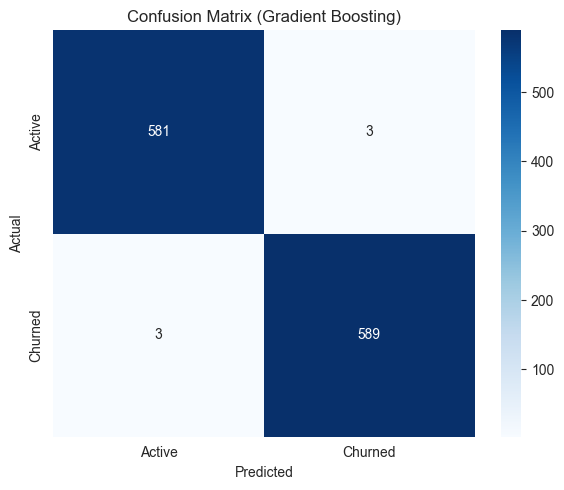

In [73]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churned"],
    yticklabels=["Active", "Churned"]
)

plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The confusion matrix provides a detailed breakdown of the model's predictions. It shows how many customers were correctly classified as active or churned, as well as the number of incorrect predictions.

This visualization helps identify whether the model is better at detecting active customers, churned customers, or both.

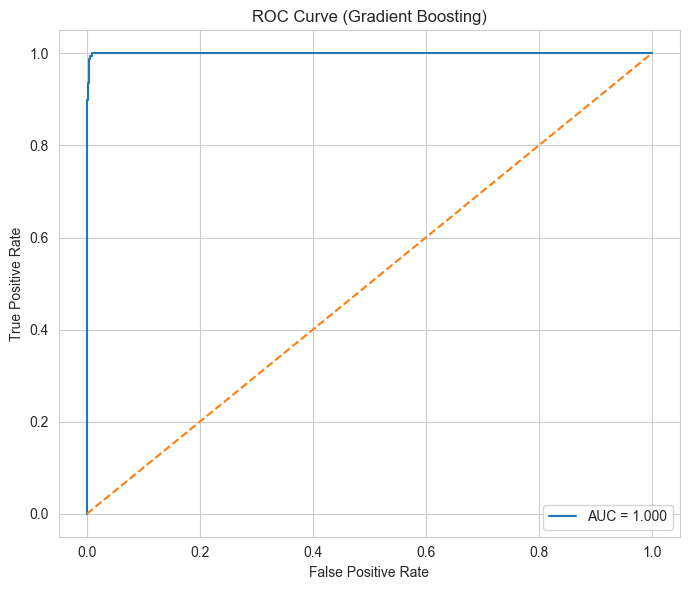

In [74]:
# ROC Curve

best_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, best_probabilities)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, best_probabilities):.3f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"ROC Curve ({best_model_name})")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The ROC curve illustrates how well the selected model distinguishes between active and churned customers across different classification thresholds.

A curve closer to the top-left corner and a higher ROC-AUC score indicate stronger classification performance and better separation between the two customer classes.

### Section Summary

In this section, we evaluated all trained classification models using multiple performance metrics. We compared their Accuracy, Precision, Recall, F1-Score, and ROC-AUC scores, automatically selected the best-performing model, and further examined its performance using a classification report, confusion matrix, and ROC curve.

This comprehensive evaluation ensures that the chosen model is not only accurate but also effective at identifying customers who are likely to churn.

# 12. Model Comparison

After evaluating all classification models, we compare their performance using a single summary table and visualization.

Comparing multiple models helps us identify the most suitable algorithm for customer churn prediction based on several evaluation metrics rather than relying on a single metric.

In [75]:
# Display evaluation results

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9949,0.9949,0.9949,0.9949,0.9997
1,Random Forest,0.9940,0.9916,0.9966,0.9941,0.9996
2,Logistic Regression,0.9745,0.9965,0.9527,0.9741,0.9985
3,Extra Trees,0.9728,0.9930,0.9527,0.9724,0.9985
4,Decision Tree,0.9881,0.9915,0.9848,0.9881,0.9881


### Observation

The table above summarizes the performance of all trained classification models. By comparing multiple evaluation metrics together, we can better understand the strengths and weaknesses of each model before selecting the final model for deployment.

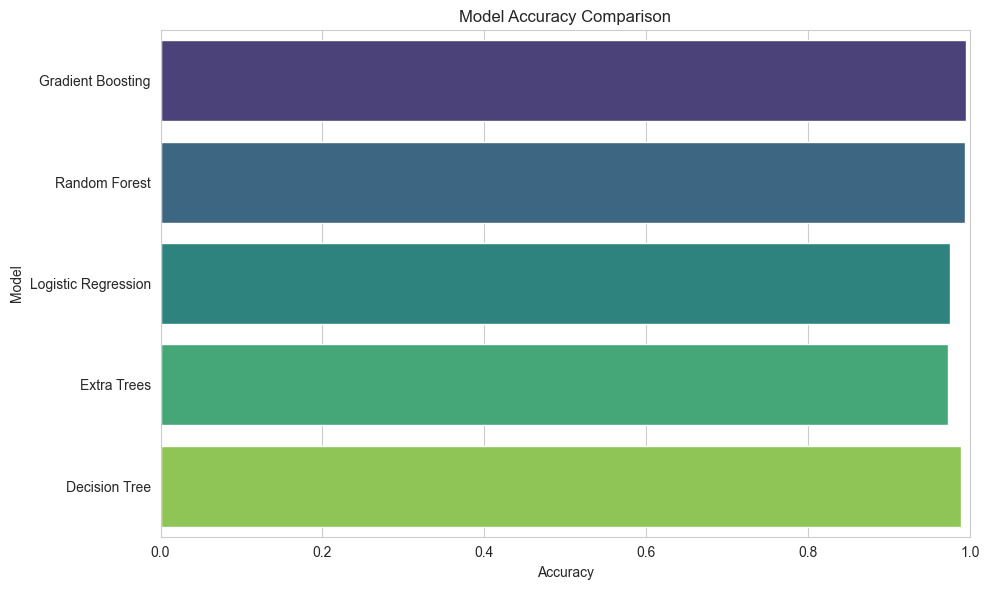

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

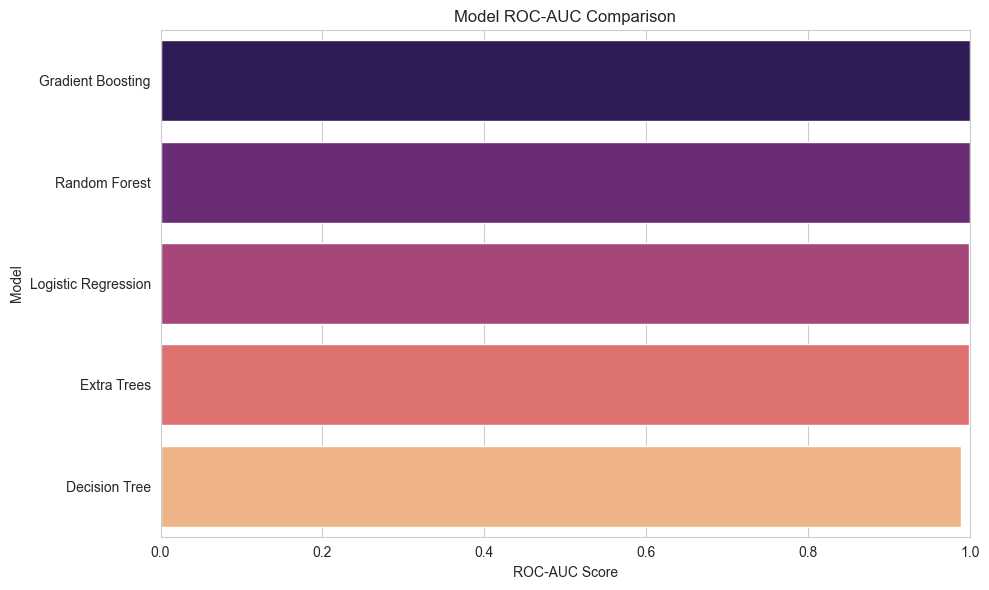

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model",
    palette="magma"
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_comparison_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
comparison_df = results_df.set_index("Model")

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.9949,0.9949,0.9949,0.9949,0.9997
Random Forest,0.9940,0.9916,0.9966,0.9941,0.9996
Logistic Regression,0.9745,0.9965,0.9527,0.9741,0.9985
Extra Trees,0.9728,0.9930,0.9527,0.9724,0.9985
Decision Tree,0.9881,0.9915,0.9848,0.9881,0.9881


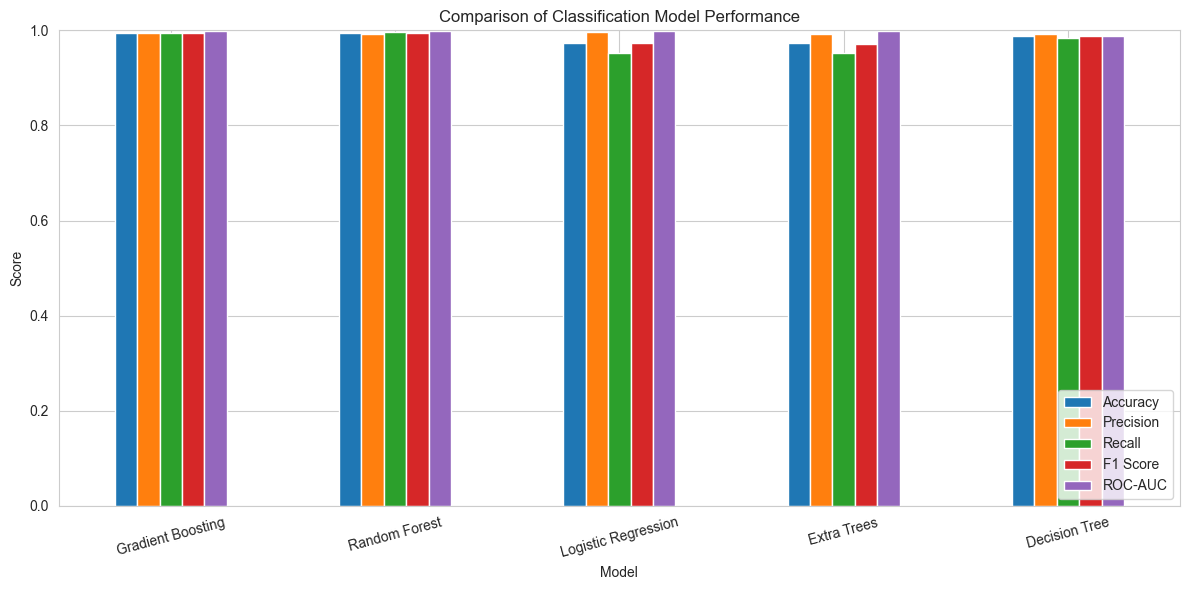

In [79]:
comparison_df.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Classification Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The comparison charts make it easier to identify the best-performing model across different evaluation metrics.

Instead of focusing only on accuracy, we also consider Precision, Recall, F1-Score, and ROC-AUC. For churn prediction, Recall and ROC-AUC are particularly important because correctly identifying customers who are likely to churn is often more valuable than simply maximizing overall accuracy.

In [80]:
print("=" * 50)
print("Best Model Selected")
print("=" * 50)

display(results_df.head(1))

Best Model Selected


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9949,0.9949,0.9949,0.9949,0.9997


In [81]:
best_model_metrics = results_df.iloc[0]

print(f"Model      : {best_model_metrics['Model']}")
print(f"Accuracy   : {best_model_metrics['Accuracy']:.4f}")
print(f"Precision  : {best_model_metrics['Precision']:.4f}")
print(f"Recall     : {best_model_metrics['Recall']:.4f}")
print(f"F1 Score   : {best_model_metrics['F1 Score']:.4f}")
print(f"ROC-AUC    : {best_model_metrics['ROC-AUC']:.4f}")

Model      : Gradient Boosting
Accuracy   : 0.9949
Precision  : 0.9949
Recall     : 0.9949
F1 Score   : 0.9949
ROC-AUC    : 0.9997


### Observation

Based on the evaluation metrics, the model shown above has been selected as the best-performing classifier for this project.

This model provides the best overall balance between correctly identifying churned customers and minimizing incorrect predictions. It will be used in the remaining sections to generate customer churn predictions and will be saved for deployment in the Streamlit dashboard and FastAPI backend.

### Section Summary

In this section, we compared the performance of all classification models using both tabular summaries and visualizations. Multiple evaluation metrics were considered to ensure a fair comparison, and the best-performing model was identified based on its overall performance.

This comparison step ensures that the final model chosen for deployment is supported by objective evaluation rather than assumptions, making the machine learning pipeline more reliable and easier to justify during interviews or business presentations.

# 13. Feature Importance Analysis

Feature importance helps us understand which customer characteristics have the greatest influence on churn prediction.

By identifying the most important features, businesses can better understand customer behaviour and focus their retention strategies on the factors that have the highest impact on customer churn.

In [82]:
# Display the best model
best_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [83]:
# Check if the model supports feature importance

hasattr(best_model, "feature_importances_")

True

In [84]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Recency,0.990001
23,CancellationRate,0.003706
12,MinRevenue,0.001713
18,PurchaseSpan,0.000774
7,MinQuantity,0.000686
22,CancelledRevenue,0.000488
1,Frequency,0.000369
10,MedianRevenue,0.000306
9,AvgRevenue,0.000301
17,ActiveMonths,0.000277


### Observation

The table above lists the features that contribute the most to the churn prediction model.

Features with higher importance scores have a greater influence on the model's decision-making process and therefore provide valuable business insights into customer behaviour.

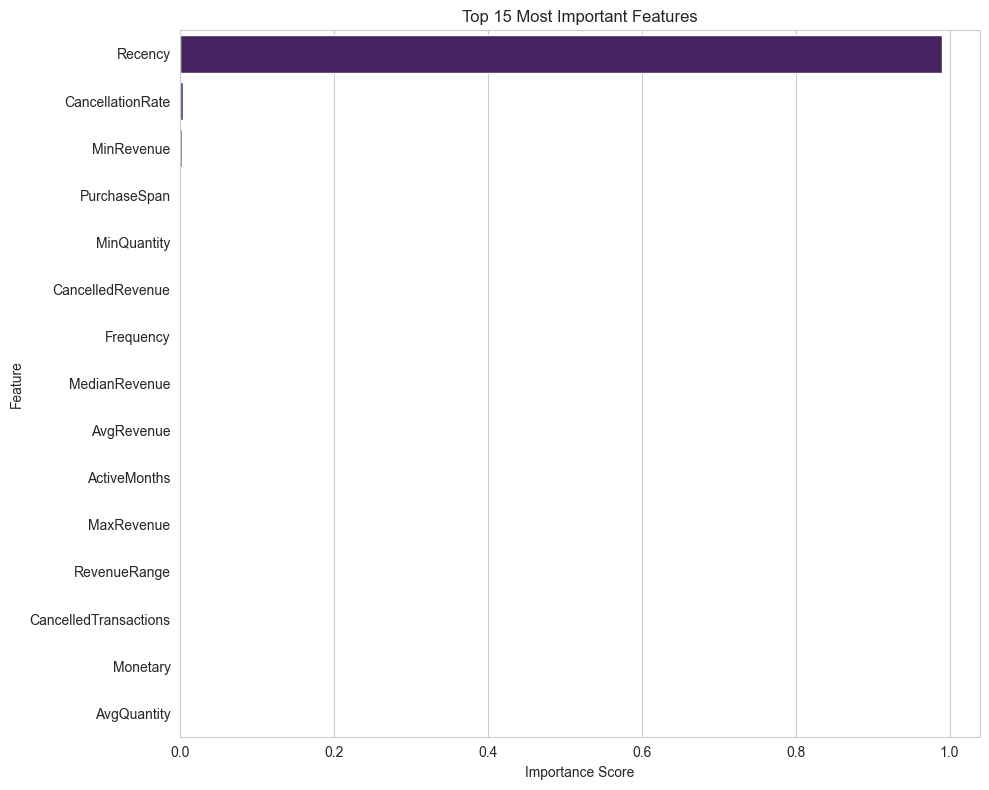

In [85]:
# Plot feature importance

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The visualization clearly highlights the features that have the greatest influence on predicting customer churn.

Business teams can use these insights to understand which customer behaviours indicate a higher risk of churn and design targeted retention campaigns accordingly.

In [86]:
# Display the ten most important features

feature_importance.head(10).reset_index(drop=True)

,Feature,Importance
0,Recency,0.990001
1,CancellationRate,0.003706
2,MinRevenue,0.001713
3,PurchaseSpan,0.000774
4,MinQuantity,0.000686
5,CancelledRevenue,0.000488
6,Frequency,0.000369
7,MedianRevenue,0.000306
8,AvgRevenue,0.000301
9,ActiveMonths,0.000277


In [87]:
# Display the least important features

feature_importance.tail(10).reset_index(drop=True)

,Feature,Importance
0,AvgQuantity,1.137375e-04
1,MedianQuantity,1.061534e-04
2,QuantitySTD,9.746252e-05
3,UniqueProducts,8.194887e-05
4,AvgProductsPerInvoice,6.721813e-05
5,MaxQuantity,6.561658e-05
6,AvgDaysBetweenPurchases,5.626970e-05
7,TotalQuantity,4.138977e-05
8,RevenueSTD,1.271088e-07
9,WeekendPurchaseRate,0.000000e+00


### Observation

Not every feature contributes equally to the prediction process. Some features have very low importance scores, indicating that they provide little additional information to the model.

Such features could be considered for removal in future experiments to simplify the model without significantly affecting its performance.

In [88]:
# Calculate cumulative importance

feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"].cumsum()
)

feature_importance.head(15)

,Feature,Importance,Cumulative Importance
0,Recency,0.990001,0.990001
23,CancellationRate,0.003706,0.993707
12,MinRevenue,0.001713,0.995419
18,PurchaseSpan,0.000774,0.996194
7,MinQuantity,0.000686,0.996880
22,CancelledRevenue,0.000488,0.997368
1,Frequency,0.000369,0.997738
10,MedianRevenue,0.000306,0.998044
9,AvgRevenue,0.000301,0.998345
17,ActiveMonths,0.000277,0.998622


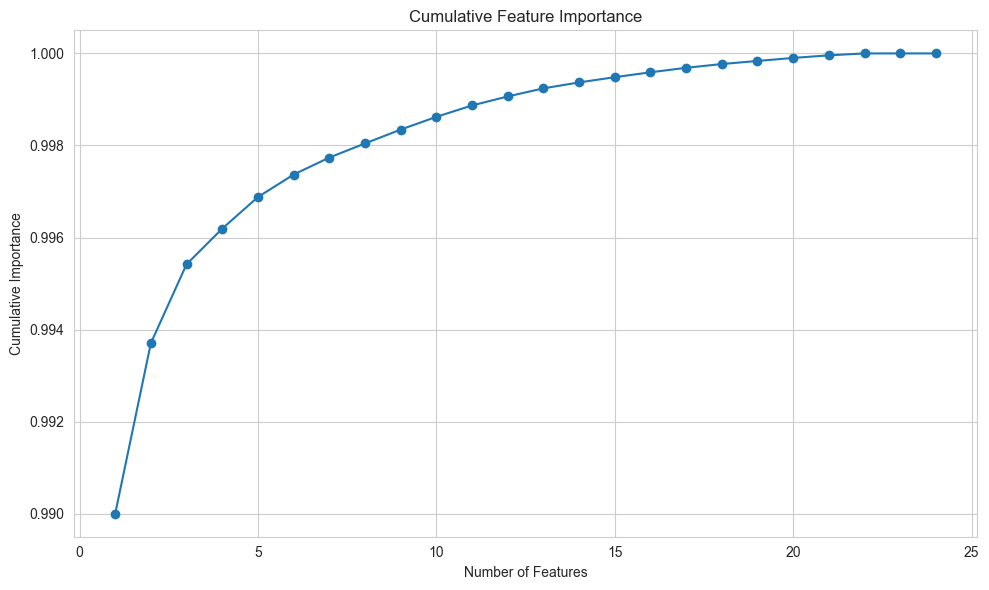

In [89]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(feature_importance) + 1),
    feature_importance["Cumulative Importance"],
    marker="o"
)

plt.title("Cumulative Feature Importance")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/figures/cumulative_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The cumulative importance curve shows how quickly the model captures most of its predictive power.

If a relatively small number of features account for a large percentage of the total importance, future versions of the model could potentially be simplified by using only those key features.

### Section Summary

In this section, we examined the importance of each feature used by the best-performing classification model. We identified the most influential customer characteristics, visualized their importance, and explored how much each feature contributed to the model's predictions.

Feature importance not only improves the interpretability of the machine learning model but also provides valuable business insights that can support customer retention strategies and future feature engineering efforts.

# 14. Generate Customer Churn Predictions

After selecting the best-performing model, we use it to predict the churn status of every customer.

In addition to the predicted class, we also calculate the probability of churn. This probability helps businesses rank customers based on their churn risk and prioritize retention efforts for customers who are most likely to leave.

In [90]:
# Prepare feature matrix for all customers

prediction_features = customer_churn_dataset.drop(
    columns=["CustomerID", "Churn", "Country"],
    errors="ignore"
)

prediction_features.head()

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate
0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,6463.038333,...,77182.60,27,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765
1,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,615.191250,...,1069.50,126,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000
2,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,403.880000,...,670.64,25,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000
3,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,1107.172500,...,1557.55,138,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000
4,310,1,334.40,197,11.588235,12.0,24,1,4.345383,334.400000,...,0.00,17,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000


In [91]:
# Scale the features using the saved scaler

prediction_features_scaled = scaler.transform(
    prediction_features
)

In [92]:
# Predict customer churn

predicted_churn = best_model.predict(
    prediction_features_scaled
)

In [93]:
# Predict churn probability

if hasattr(best_model, "predict_proba"):

    churn_probability = best_model.predict_proba(
        prediction_features_scaled
    )[:, 1]

else:
    # Fallback for models without predict_proba
    churn_probability = np.zeros(
        len(predicted_churn)
    )

In [94]:
customer_predictions = pd.DataFrame({

    "CustomerID":
    customer_churn_dataset["CustomerID"],

    "ActualChurn":
    customer_churn_dataset["Churn"],

    "PredictedChurn":
    predicted_churn,

    "ChurnProbability":
    churn_probability.round(4)

})

customer_predictions.head()

,CustomerID,ActualChurn,PredictedChurn,ChurnProbability
0,12346.0,1,1,0.9973
1,12347.0,0,0,0.0004
2,12348.0,0,0,0.0005
3,12349.0,0,0,0.0004
4,12350.0,1,1,0.9992


In [95]:
customer_predictions["PredictedStatus"] = customer_predictions[
    "PredictedChurn"
].map({
    0: "Active",
    1: "Churned"
})

customer_predictions.head()

,CustomerID,ActualChurn,PredictedChurn,ChurnProbability,PredictedStatus
0,12346.0,1,1,0.9973,Churned
1,12347.0,0,0,0.0004,Active
2,12348.0,0,0,0.0005,Active
3,12349.0,0,0,0.0004,Active
4,12350.0,1,1,0.9992,Churned


In [96]:
# Top 10 customers with highest churn probability

high_risk_customers = customer_predictions.sort_values(
    by="ChurnProbability",
    ascending=False
)

high_risk_customers.head(10)

,CustomerID,ActualChurn,PredictedChurn,ChurnProbability,PredictedStatus
4228,16617.0,1,1,0.9997,Churned
2033,14402.0,1,1,0.9996,Churned
5603,18012.0,1,1,0.9996,Churned
2036,14405.0,1,1,0.9996,Churned
248,12595.0,1,1,0.9996,Churned
149,12496.0,1,1,0.9996,Churned
1935,14302.0,1,1,0.9996,Churned
991,13346.0,1,1,0.9996,Churned
2565,14941.0,1,1,0.9996,Churned
4310,16699.0,1,1,0.9996,Churned


### Observation

The table above lists the customers with the highest probability of churning.

Rather than treating all customers equally, businesses can focus their retention efforts on these high-risk customers by offering personalized promotions, loyalty rewards, or targeted marketing campaigns.

In [97]:
customer_predictions.to_csv(
    "../data/processed/customer_churn_predictions.csv",
    index=False
)

print("Customer churn predictions saved successfully.")

Customer churn predictions saved successfully.


In [98]:
print("Prediction Dataset Shape :", customer_predictions.shape)

customer_predictions.head()

Prediction Dataset Shape : (5878, 5)


,CustomerID,ActualChurn,PredictedChurn,ChurnProbability,PredictedStatus
0,12346.0,1,1,0.9973,Churned
1,12347.0,0,0,0.0004,Active
2,12348.0,0,0,0.0005,Active
3,12349.0,0,0,0.0004,Active
4,12350.0,1,1,0.9992,Churned


### Section Summary

In this section, we generated churn predictions for every customer using the best-performing classification model. Along with the predicted churn class, we also calculated each customer's probability of churning.

The final prediction dataset was saved for future use in the Streamlit dashboard, FastAPI backend, and business reporting. Ranking customers by churn probability enables businesses to prioritize retention efforts and make more informed marketing decisions.

# 15. Save the Final Model

After identifying the best-performing classification model, the final step is to save it for future use.

Saving the trained model allows us to reuse it without retraining, making it easy to integrate with the Streamlit dashboard, FastAPI backend, and future prediction pipelines.

Along with the model, we also verify that it can be successfully loaded back into memory.

In [99]:
# Save the best model

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

print("Churn model saved successfully!")

Churn model saved successfully!


In [100]:
# Load the saved model

loaded_model = joblib.load(
    "../models/churn_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [101]:
# Verify the loaded model

print("Original Model :", type(best_model).__name__)
print("Loaded Model   :", type(loaded_model).__name__)

Original Model : GradientBoostingClassifier
Loaded Model   : GradientBoostingClassifier


In [102]:
# Verify that the loaded model produces the same predictions

loaded_predictions = loaded_model.predict(
    prediction_features_scaled
)

same_predictions = np.array_equal(
    predicted_churn,
    loaded_predictions
)

print("Predictions Match :", same_predictions)

Predictions Match : True


### Observation

The saved model was successfully loaded and produced the same predictions as the original model. This confirms that the serialization process was successful and that the model can be reliably reused without retraining.

In [103]:
from pathlib import Path

print("Saved Model Files")
print("-" * 30)

for file in Path("../models").glob("churn*"):
    print(file.name)

Saved Model Files
------------------------------
churn_model.pkl
churn_scaler.pkl


### Section Summary

In this section, we saved the best-performing churn prediction model as `churn_model.pkl` and verified that it could be loaded successfully. We also confirmed that the loaded model generated the same predictions as the original model, ensuring that it is ready for deployment.

By saving both the trained model and the scaler, we have created a reusable machine learning pipeline that can be integrated into web applications and APIs without retraining.

# 16. Business Insights & Conclusion

In this final section, we summarize the key findings from the Customer Churn Prediction project and discuss how the developed machine learning model can support business decision-making.

Beyond achieving good predictive performance, the primary objective of churn prediction is to help businesses identify at-risk customers early and take proactive actions to improve customer retention and maximize long-term profitability.

## Key Business Insights

### 1. Churn Prediction Enables Proactive Customer Retention

Instead of waiting for customers to become inactive, the model identifies customers who are most likely to churn. This allows businesses to intervene before losing valuable customers.

---

### 2. Customer Behaviour is a Strong Indicator of Churn

Features such as purchase frequency, recency, total spending, product diversity, and purchasing behaviour provide valuable information for predicting whether a customer is likely to stop purchasing.

---

### 3. High-Risk Customers Can Be Prioritized

Using churn probabilities, customers can be ranked according to their risk level. Marketing teams can focus their efforts on customers who have the highest probability of leaving instead of targeting the entire customer base.

---

### 4. Data-Driven Decision Making

The machine learning model enables businesses to replace intuition with data-driven insights, leading to more effective customer retention strategies and better allocation of marketing resources.

---

### 5. Integration with Other Analytics Models

The churn prediction model complements the Customer Segmentation and Customer Lifetime Value (CLV) models developed in earlier phases.

Together, these models provide a comprehensive understanding of customer behaviour and business performance.

## Business Recommendations

Based on the results of this project, the following strategies can help reduce customer churn:

- Offer personalized discounts to high-risk customers.
- Launch targeted email and promotional campaigns.
- Improve loyalty and reward programs.
- Recommend products based on previous purchases.
- Monitor customers with declining purchase frequency.
- Regularly retrain the model using updated transaction data.

## Project Achievements

During this phase, we successfully:

- Defined customer churn using a business-driven rule.
- Created the customer churn dataset.
- Prepared customer-level features for classification.
- Trained multiple machine learning models.
- Evaluated models using multiple performance metrics.
- Selected the best-performing model.
- Generated churn predictions and churn probabilities.
- Identified high-risk customers.
- Saved the trained model and scaler for deployment.

## Conclusion

In this phase, we developed an end-to-end Customer Churn Prediction pipeline using supervised machine learning techniques.

Starting from cleaned transaction data, we created a customer-level modeling dataset, defined a churn target, trained multiple classification models, evaluated their performance, and selected the best model for deployment.

The final solution not only predicts whether a customer is likely to churn but also estimates the probability of churn, enabling businesses to prioritize retention efforts more effectively.

The trained model and preprocessing pipeline are now ready to be integrated into the Streamlit dashboard and FastAPI backend developed in the upcoming phases of the project.

In [107]:
# ==========================================================
# SAVE CHURN ARTIFACTS
# ==========================================================

from pathlib import Path
import pandas as pd
import numpy as np

artifact_dir = Path("../artifacts/churn")
artifact_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# Customer Predictions
# ----------------------------------------------------------

churn_predictions = X_test.copy()

churn_predictions["Actual"] = y_test.values
churn_predictions["Predicted"] = y_pred
churn_predictions["Probability"] = y_prob

churn_predictions.to_csv(
    artifact_dir / "churn_predictions.csv",
    index=False
)

# ----------------------------------------------------------
# Classification Metrics
# ----------------------------------------------------------

metrics_df = pd.DataFrame(best_model_metrics)

metrics_df.to_csv(
    artifact_dir / "classification_metrics.csv",
    index=False
)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm_df = pd.DataFrame(
    confusion_matrix,
    columns=["Predicted_0", "Predicted_1"],
    index=["Actual_0", "Actual_1"]
)

cm_df.to_csv(
    artifact_dir / "confusion_matrix.csv"
)

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

if isinstance(feature_importance, pd.DataFrame):

    feature_importance.to_csv(
        artifact_dir / "feature_importance.csv",
        index=False
    )

else:

    feature_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": feature_importance
    })

    feature_df.to_csv(
        artifact_dir / "feature_importance.csv",
        index=False
    )

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_df = pd.DataFrame({

    "FPR": fpr,

    "TPR": tpr,

    "Threshold": thresholds

})

roc_df.to_csv(
    artifact_dir / "roc_curve.csv",
    index=False
)

print("="*60)
print("Churn artifacts saved successfully.")
print("="*60)
print("Files Saved:")
print("churn_predictions.csv")
print("classification_metrics.csv")
print("confusion_matrix.csv")
print("feature_importance.csv")
print("roc_curve.csv")
print("="*60)

Churn artifacts saved successfully.
Files Saved:
churn_predictions.csv
classification_metrics.csv
confusion_matrix.csv
feature_importance.csv
roc_curve.csv
